# Calcolo della f0 su tutto il dataset

In [137]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee

In [138]:
%matplotlib widget
plt.close('all')

Abbiamo alcune opzioni da confrontare per il calcolo della f0, tra cui:
- primo picco dello spettro di potenza
- gcd approx
- regressione lineare
- bayesiano

In [139]:
def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None

def get_f0_from_gcd(peak_freqs):
    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per calcolare la f0

    peak_freqs = peak_freqs[:5]

    fmin = np.min(peak_freqs) / 2
    fmax = np.min(peak_freqs)
    candidates = np.arange(fmin, fmax, 0.05)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residuals = [f/f0 - round(f/ f0) for f in peak_freqs if f > f0]
        residual = sum(residuals)

        if residual < best_score and np.round(peak_freqs / f0).min() > 0:  # Assicurati che ci siano armoniche valide
            best_score = residual
            best_f0 = f0
    
    return best_f0

def get_f0_linear_regression(peak_freqs):

    peak_freqs = peak_freqs[:5]

    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per la regressione lineare
    x = np.arange(1, len(peak_freqs) + 1)
    y = peak_freqs
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0] # m è la pendenza (f0 stimata), c è l'intercetta
    return m  # La pendenza della retta è la f0 stimata


In [140]:

def get_limiti_prior(observed_freqs):
    f_min = np.min(observed_freqs) * 0.5
    f_max = np.min(observed_freqs) * 2

    log_sigma_min = np.log(0.1)   # 0.1 Hz
    log_sigma_max = np.log(100)   # 100 Hz

    log_uniform = -np.log(f_max - f_min)

    ns_max = len(observed_freqs) # massimo numero di picchi osservati inizialmente

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform

def init_bayesian(observed_freqs, nwalkers=50):
    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(observed_freqs)

    n_max = len(observed_freqs)

    ns = np.arange(1, n_max + 1) # indice per gestire i picchi

    log_norm_const = -0.5 * np.log(2.0 * np.pi)

    def log_prob_vect(theta_batch):
        theta_batch = np.atleast_2d(theta_batch) # assicura che sia 2D anche se viene passato un singolo punto

        f0 = theta_batch[:, 0] # primo parametro: f0
        log_sigma = theta_batch[:, 1] # secondo parametro: log(sigma)
        q = theta_batch[:, 2] # terzo parametro: q (mixing coefficient)

        logp = np.full(theta_batch.shape[0], -np.inf, dtype=float) # inizializza logp con -inf per i casi non validi

        valid = (
            (f0 > f_min) & (f0 < f_max) &
            (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
            (q > 0.0) & (q < 1.0)
        )

        if not np.any(valid):
            return logp

        f0v = f0[valid]
        log_sigmav = log_sigma[valid]
        qv = q[valid]

        sigma = np.exp(log_sigmav)

        # expected shape: (Wv, N)
        expected = f0v[:, None] * ns[None, :] # genera le frequenze attese per ogni armonica data f0

        # residuals shape: (Wv, K, N)
        residuals = observed_freqs[None, :, None] - expected[:, None, :] # calcola i residui tra frequenze osservate e attese

        # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
        log_gauss = (
            -0.5 * (residuals / sigma[:, None, None]) ** 2
            - np.log(sigma)[:, None, None]
            + log_norm_const
        )

        # log media su n: log(1/N * sum_n ...)
        log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

        # miscela q * harmonic + (1-q) * uniforme in log-space
        log_mix = np.logaddexp(
            np.log(qv)[:, None] + log_harm,
            np.log1p(-qv)[:, None] + log_uniform
        )  # (Wv, K)

        logp[valid] = np.sum(log_mix, axis=1)
        return logp
    
    ndim = 3  # f0, log_sigma, q

    p0 = np.column_stack([
    np.random.normal(observed_freqs[0], observed_freqs[0] * 0.8, nwalkers),
    np.random.normal(np.log(1), 0.5, nwalkers),
    np.random.uniform(0.5, 1.0, nwalkers)
    ])

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_prob_vect,
        vectorize=True,
    )

    return sampler, p0

def get_f0_bayesian(peak_freqs, nwalkers=50, nsteps=100):
    try:
        peak_freqs = np.array(peak_freqs[:10])
        peak_freqs = peak_freqs
        sampler, p0 = init_bayesian(peak_freqs, nwalkers=nwalkers)
        state = sampler.run_mcmc(p0, nsteps, progress=False)
        samples = sampler.get_chain(discard=nsteps//4, flat=True)

        f0_samples = samples[:, 0]
        f0_estimate = np.median(f0_samples)

        q_samples = samples[:, 2]
        q_estimate = np.median(q_samples)

        #print(f"F0 stimata: {f0_estimate:.2f} Hz, q stimato: {q_estimate:.2f}")

        return f0_estimate

    except Exception as e:
        print(f"Errore nell'inferenza bayesiana: {e}")
        return None

# def get_f0_bayesian_map(peak_freqs):

#     # metodo bayesiano che cerca solo il max della posterior, invece di campionare.
#     # molto veloce rispetto a emcee

#     f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

#     n_max = len(peak_freqs)

#     ns = np.arange(1, n_max + 1)

#     log_norm_const = -0.5 * np.log(2.0 * np.pi)

#     def log_prob_vect(theta_batch):
#         theta_batch = np.atleast_2d(theta_batch)

#         f0 = theta_batch[:, 0]
#         log_sigma = theta_batch[:, 1]
#         q = theta_batch[:, 2]

#         logp = np.full(theta_batch.shape[0], -np.inf, dtype=float)

#         valid = (
#             (f0 > f_min) & (f0 < f_max) &
#             (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
#             (q > 0.0) & (q < 1.0)
#         )

#         if not np.any(valid):
#             return logp

#         f0v = f0[valid]
#         log_sigmav = log_sigma[valid]
#         qv = q[valid]

#         sigma = np.exp(log_sigmav)

#         # expected shape: (Wv, N)
#         expected = f0v[:, None] * ns[None, :]

#         # residuals shape: (Wv, K, N)
#         residuals = peak_freqs[None, :, None] - expected[:, None, :]

#         # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
#         log_gauss = (
#             -0.5 * (residuals / sigma[:, None, None]) ** 2
#             - np.log(sigma)[:, None, None]
#             + log_norm_const
#         )

#         # log media su n: log(1/N * sum_n ...)
#         log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

#         # miscela q * harmonic + (1-q) * uniforme in log-space
#         log_mix = np.logaddexp(
#             np.log(qv)[:, None] + log_harm,
#             np.log1p(-qv)[:, None] + log_uniform
#         )  # (Wv, K)

#         logp[valid] = np.sum(log_mix, axis=1)
#         return logp

#     log_prob = lambda theta: log_prob_vect(theta[None, :])[0]
#     result = sp.optimize.minimize(lambda theta: -log_prob(theta), x0=[peak_freqs[0], np.log(50), 0.5], method='Nelder-Mead')
#     print(f"F0 stimata (MAP): {result.x[0]:.4f} +- {result.x[1]:.4f} Hz. q stimato: {result.x[2]:.4f}")
#     return result.x[0]


In [ ]:
from scipy.special import logsumexp


def get_f0_bayesian_map(peak_freqs):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

    # Parametri delle armoniche
    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = -np.log(len(ns))     # Probabilità uniforme P(n)
    U_log = log_uniform # Probabilità uniforme del rumore
    q_min = 1e-3
    q_max = 1.0 - 1e-3

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:
            # Calcoliamo log(N(fk | n*f0, sigma)) per ogni n in modo stabile
            # Formula: -0.5 * ((x-mu)/sigma)^2 - log(sigma * sqrt(2*pi))
            log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            # Somma delle armoniche: log(sum(P_n * Gauss))
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            # Miscela: log(q * p_harm + (1-q) * p_unif)
            # logaddexp(a, b) calcola log(exp(a) + exp(b))
            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood

    f_start = peak_freqs[0]
    sigma_start = np.log(1.0)

    # Seed data-driven di q per evitare che il MAP resti bloccato su un valore fisso.
    q_grid = np.linspace(q_min, q_max, 25)
    q_scores = [log_prob([f_start, sigma_start, q]) for q in q_grid]
    q_start = float(q_grid[int(np.argmax(q_scores))])

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.2f}Hz, q: {q_map:.8f}")

    return f0_map

In [47]:
base_dir = "dati_processati"
peak_file = "spettri_10_periodi_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [48]:
# calcola f0 per ogni campione usando i diversi metodi
f0_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs, freqs, mags),
        'gcd': get_f0_from_gcd(freqs),
        'linear_regression': get_f0_linear_regression(freqs),
        'bayesian': get_f0_bayesian(freqs),
        'bayesian_map': get_f0_bayesian_map(freqs)
    }

Processing Nota_1...
MAP Singolo -> F0: 1568.63Hz, Sigma: 0.10Hz, q: 0.14102699
Processing Nota_2...
MAP Singolo -> F0: 1490.68Hz, Sigma: 0.10Hz, q: 0.10911359
Processing Nota_3...
MAP Singolo -> F0: 330.59Hz, Sigma: 0.72Hz, q: 0.12129393
Processing Nota_4...
MAP Singolo -> F0: 169.54Hz, Sigma: 0.82Hz, q: 0.00100001
Processing Nota_5...
MAP Singolo -> F0: 224.72Hz, Sigma: 0.76Hz, q: 0.00100003
Processing Nota_6...
MAP Singolo -> F0: 467.38Hz, Sigma: 0.10Hz, q: 0.47423654
Processing Nota_7...
MAP Singolo -> F0: 176.15Hz, Sigma: 0.10Hz, q: 0.09715535
Processing Nota_8...
MAP Singolo -> F0: 784.31Hz, Sigma: 0.22Hz, q: 0.22611371
Processing Nota_9...
MAP Singolo -> F0: 156.56Hz, Sigma: 0.29Hz, q: 0.00100004
Processing Nota_10...
MAP Singolo -> F0: 233.63Hz, Sigma: 0.10Hz, q: 0.09704554
Processing Nota_11...
MAP Singolo -> F0: 1403.51Hz, Sigma: 0.10Hz, q: 0.18556056
Processing Nota_12...
MAP Singolo -> F0: 1179.36Hz, Sigma: 0.10Hz, q: 0.63533161
Processing Nota_13...
MAP Singolo -> F0: 524.

In [49]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1568.627450980392
  gcd: 822.2637254901615
  linear_regression: 1559.2156862745096
  bayesian: 1864.62174856671
  bayesian_map: 1568.6274508024565
Nota_2:
  first_peak: 1490.6832298136646
  gcd: 781.3916149067995
  linear_regression: 1484.72049689441
  bayesian: 1800.8892077712449
  bayesian_map: 1490.6832298149764
Nota_3:
  first_peak: 330.8063404548587
  gcd: 174.10317022743132
  linear_regression: 330.80634045485857
  bayesian: 385.94475081293257
  bayesian_map: 330.59445228166214
Nota_4:
  first_peak: 169.53642384105962
  gcd: 91.41821192052943
  linear_regression: 174.83443708609278
  bayesian: 215.91542419841704
  bayesian_map: 169.53642384105962
Nota_5:
  first_peak: 224.71910112359552
  gcd: 147.40955056179575
  linear_regression: 220.2247191011236
  bayesian: 306.7772284108984
  bayesian_map: 224.71910112359552
Nota_6:
  first_peak: 467.3807205452775
  gcd: 249.24036027264228
  linear_regression: 337.4488802336903
  bayesian: 467.47182464957524
  bayesian

In [50]:
# cstruisci un dizionario con le frequenze delle note dalla prima ottava fino alla quinta, sfruttando l'andamento esponenziale delle frequenze
note_freqs = {}
for octave in range(1, 7):
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in note_freqs.items():
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO1: 32.70 Hz
  DO#1: 34.64 Hz
  RE1: 36.70 Hz
  RE#1: 38.89 Hz
  MI1: 41.20 Hz
  FA1: 43.65 Hz
  FA#1: 46.24 Hz
  SOL1: 48.99 Hz
  SOL#1: 51.91 Hz
  LA1: 54.99 Hz
  LA#1: 58.26 Hz
  SI1: 61.73 Hz
  DO2: 65.40 Hz
  DO#2: 69.29 Hz
  RE2: 73.41 Hz
  RE#2: 77.77 Hz
  MI2: 82.40 Hz
  FA2: 87.30 Hz
  FA#2: 92.49 Hz
  SOL2: 97.99 Hz
  SOL#2: 103.82 Hz
  LA2: 109.99 Hz
  LA#2: 116.53 Hz
  SI2: 123.46 Hz
  DO3: 130.80 Hz
  DO#3: 138.58 Hz
  RE3: 146.82 Hz
  RE#3: 155.55 Hz
  MI3: 164.80 Hz
  FA3: 174.60 Hz
  FA#3: 184.98 Hz
  SOL3: 195.98 Hz
  SOL#3: 207.63 Hz
  LA3: 219.98 Hz
  LA#3: 233.06 Hz
  SI3: 246.92 Hz
  DO4: 261.60 Hz
  DO#4: 277.16 Hz
  RE4: 293.64 Hz
  RE#4: 311.10 Hz
  MI4: 329.60 Hz
  FA4: 349.19 Hz
  FA#4: 369.96 Hz
  SOL4: 391.96 Hz
  SOL#4: 415.26 Hz
  LA4: 439.96 Hz
  LA#4: 466.12 Hz
  SI4: 493.84 Hz
  DO5: 523.20 Hz
  DO#5: 554.31 Hz
  RE5: 587.27 Hz
  RE#5: 622.19 Hz
  MI5: 659.19 Hz
  FA5: 698.39 Hz
  FA#5: 739.92 Hz
  SOL5: 783.91 Hz
  SOL#5: 830.5

In [56]:
types = [
    "first_peak",
    "gcd",
    "linear_regression",
    "bayesian",
    "bayesian_map"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



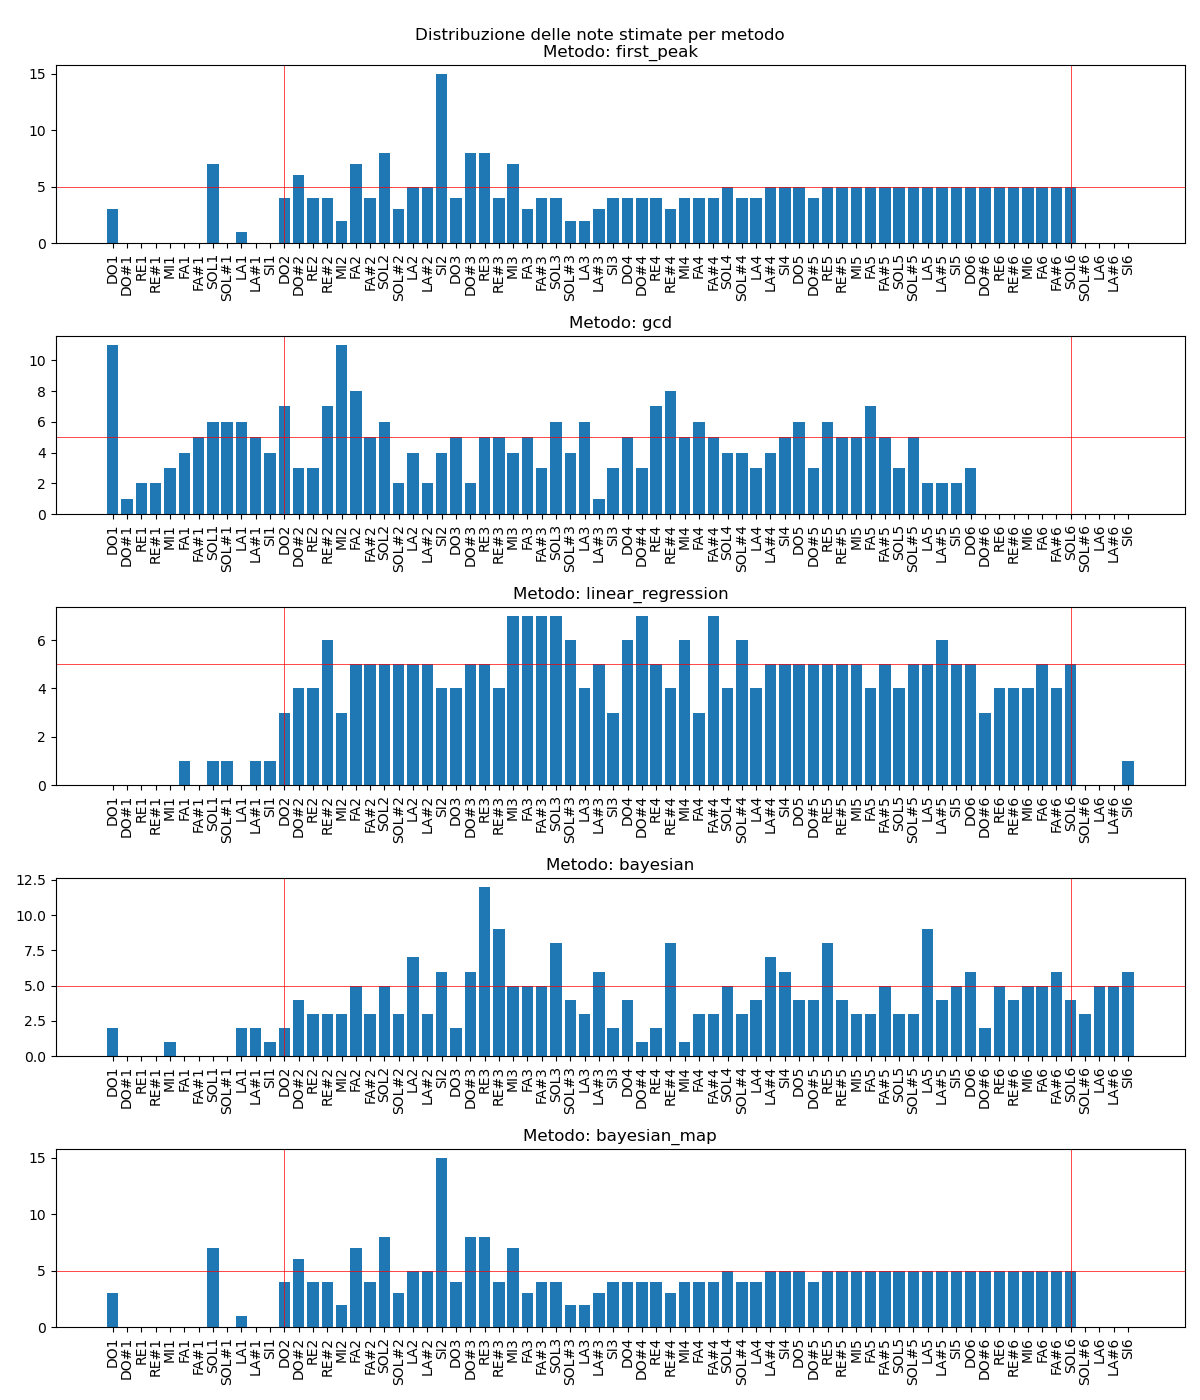

In [57]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(12, 14))

fig.suptitle("Distribuzione delle note stimate per metodo")

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8)
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='red', linewidth=0.5)
    axs[i].axvline(ordered_notes.index("DO2"), color='red', linewidth=0.5)
    axs[i].axvline(ordered_notes.index("SOL6"), color='red', linewidth=0.5)


plt.tight_layout()
plt.show()
